# Interpretation et recommandation Business


In [17]:
##============== modules basiques ===============

import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [18]:
##============= Synchronisation pour permettre les import dans src en particulier ============
# Réglages d'affichage
pd.set_option("display.max_columns", 21)
# Toujours afficher la dimension du dataframe
pd.set_option("display.show_dimensions", True)

# Chemin absolue

project_root = Path.cwd().resolve().parents[0]
src_path = project_root / "src"

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [19]:
##=========== mes modules dans SRC ==========

from src.config import RAW_DATA_PATH, TARGET_COL, RANDOM_STATE
from src.utils import load_csv
from src.features import add_features
from src.preprocessing import split_data, build_preprocessor
from src.modeling import load_model

In [20]:
##============ Chargement des données ==============

df_raw = load_csv(RAW_DATA_PATH)
df = df_raw.copy()

In [21]:
##============= Nettoyage dataset et ajout des trois variables créer lors features engineering ===============

df = add_features(df)

##======= matrice des features X & variable cible y ===========

X = df.drop(columns = [TARGET_COL])

y= df[TARGET_COL]

##=============== encodage de la variable cible ===========

y = df[TARGET_COL].map({"No": 0, "Yes": 1})

##============ Decoupage des données ======================

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, random_state=RANDOM_STATE)


## Interprétation:

- **Importance des variables**: sur la partie modélisation on a pu observé que les variables les plus importantes pour notre     modèles essentiellement par ordre décroissant sont `tenure`, `tenure_groupe`, `InternetService`, `OnelineSecurity`,           `TechSupport`, `num_services`, `engagement_level`, `OnelineBackup`. Ce qui est en cohérence avec notre EDA, autrement dit       que plus le client est récent (tenure & tenure_groupe), plus qu'il churn ou à risque. Les clients avec des contrat court       et/ou aussi avec de faibles services souscrits sont à fort risque (engagement_level).
  
- **Interprétation globales**: globalement on vois que le churn est dû au contrat court, au faible souscription des             services additionnels et le mode de paiement. **Autrement dit donc que les cients avec des contrats courts et/ou les             plus récents ou encore des clients souscritent à peu de services sont plus susceptibles de churn**.
      
- **Interprétation locale**  ces deux clients (354, 264) sont classés à haut risque de churn car :
    - ils ont une faible ancienneté  
    - ils sont en contrat mensuel  
    - ils utilisent peu de services 

In [22]:
##============== Importation du meilleur modèle ===========
best_model = load_model(project_root / "models" / "model_optimal.joblib")

In [23]:
##============== Recupération du meilleur modèle et quelques données essentielles ============

model = best_model.named_steps["model"]

X_train_trans = best_model.named_steps["preprocessor"].transform(X_train)

X_val_trans = best_model.named_steps["preprocessor"].transform(X_val)

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

In [24]:
##============ Interprétation via Shap =================

explainer = shap.Explainer(model, X_train_trans, feature_names=feature_names)



In [25]:
# calcul des valeurs SHAP sur un échantillon de validation

shap_values = explainer(X_val_trans[:200])



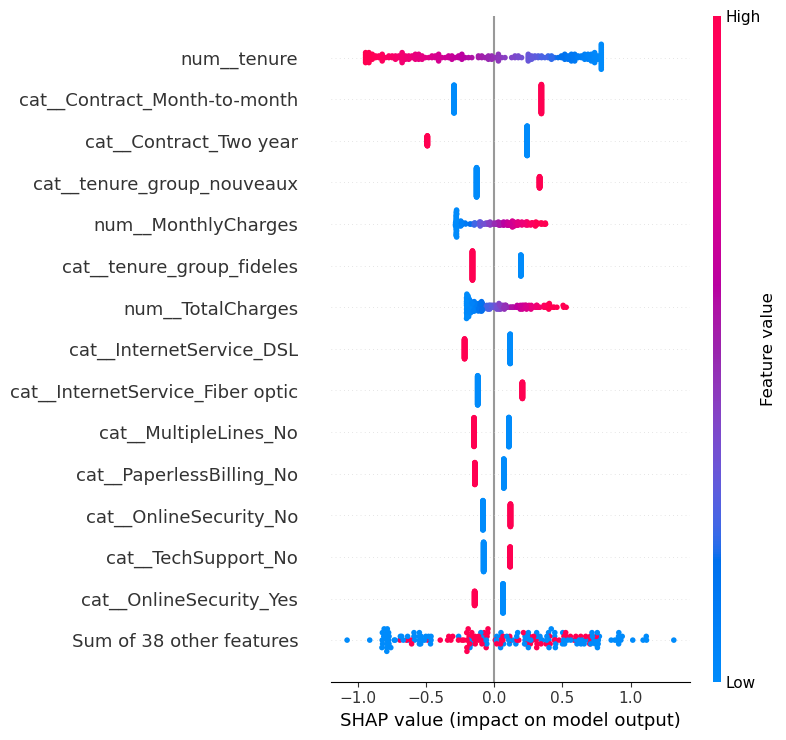

In [32]:
# graphique global
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(figures_dir / "SHAP.png", bbox_inches="tight")
plt.show()




In [27]:
##================= interprétation locale: ciblage du client 354, qui est top  churn =============

X_val.iloc[354]

best_model.predict_proba(X_val.iloc[[354]])

array([[0.04892566, 0.95107434]])

In [28]:
print( X_val.iloc[354])

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1
tenure_group                nouveaux
num_services                       4
engagement_level               moyen
Name: 3380, Length: 22, dtype: object


In [29]:
##================= interprétation locale: ciblage du client 264, en deuxieme position du churn =============

X_val.iloc[264]

best_model.predict_proba(X_val.iloc[[264]])

array([[0.05280688, 0.94719312]])

In [30]:
X_val.iloc[264]

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             7
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                 Yes
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 99.25
TotalCharges                  665.45
tenure_group                nouveaux
num_services                       5
engagement_level               moyen
Name: 2631, Length: 22, dtype: object

## Variables actionnables:

- `contrat`: actionnale -> proposer un engagement long
- `num_services`: actionnable -> proposer plus de services additionnels, avec des tarifs accessibles
- `engagement_level`: actionnable -> privilegier le mode de payement automatisé (tranfert bancaire, ou carte Crédit) et aussi     proposer des service internet qualité avec des prix accessibles
- `TechSupport`: actionnable -> renforcer ou proposer plus de services de support et d'assistance technique
- `PaperlessBilling`: partiellement actionnables -> reduire au maximun la facturation dématérialiser

## Recommandation Business

En résumé on observe que les clients récents avec des contrats mensuelles et qui sont souscrits à peu de services, ce qui peut s'expliquer par un faible engagement et de coût de sortie; et surtout peu de dépendance au services que propose l'entreprise.

Je recommande donc de **proposer des des offre de passage vers des contrats annuels avec des reductions**, **proposer des offres de rétention adaptés au clients avec des contrats mensuels**, **ajouter plus de services avec des tarifs abordables**, **améliorer l'assistance technique et le support**, **cibler les top clients à risques et à forte valeurs potentielles** et utiliser le **churn commme outil d'aide à la priorisation commerciale**.